# Zufällige Bilder aus einer Klassenliste

Dieses Notebook lädt das Galaxy10-DECals-Dataset, wählt für jede Klasse in `TARGET_CLASS_IDS` ein zufälliges Bild aus und zeigt die Bilder einzeln an.

In [16]:
import matplotlib.pyplot as plt
import numpy as np

from data import LABEL_DICT, load_data

DATA_PATH = "./../data/Galaxy10_DECals.h5"
TARGET_CLASS_IDS = [0, 6, 7]  # z.B. [0, 5, 8]
RANDOM_STATE = 1

rng = np.random.default_rng(RANDOM_STATE)

In [17]:
images_raw, labels = load_data(DATA_PATH)

if not TARGET_CLASS_IDS:
    raise ValueError("TARGET_CLASS_IDS darf nicht leer sein.")

invalid_classes = [cls_id for cls_id in TARGET_CLASS_IDS if cls_id not in LABEL_DICT]
if invalid_classes:
    raise ValueError(f"Unbekannte Klassen: {invalid_classes}. Verfügbar sind: {list(LABEL_DICT.keys())}")

samples = []
for class_id in TARGET_CLASS_IDS:
    class_indices = np.where(labels == class_id)[0]
    if len(class_indices) == 0:
        raise ValueError(f"Keine Bilder für Klasse {class_id} gefunden.")

    sample_index = int(rng.choice(class_indices))
    sample_image = images_raw[sample_index]
    samples.append((class_id, sample_index, sample_image))
    print(f"Klasse {class_id} - {LABEL_DICT[class_id]} | Zufälliger Index: {sample_index}")

Dataset geladen: 17,736 Bilder, Shape (17736, 256, 256, 3)
Klasse 0 - Disturbed Galaxies | Zufälliger Index: 511
Klasse 6 - Unbarred Tight Spiral Galaxies | Zufälliger Index: 10919
Klasse 7 - Unbarred Loose Spiral Galaxies | Zufälliger Index: 13796


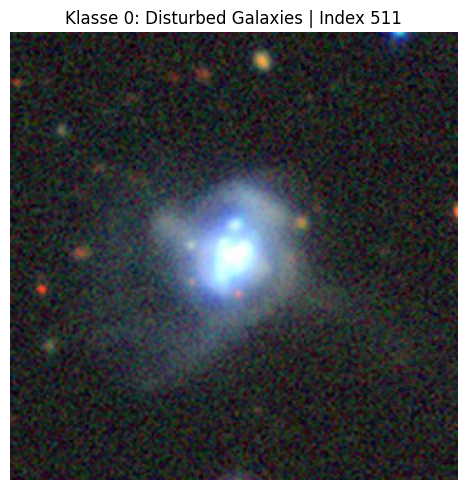

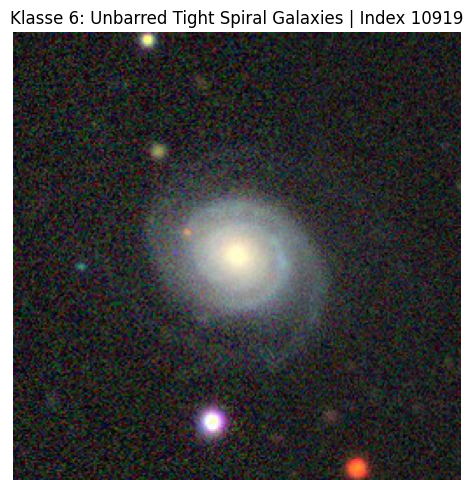

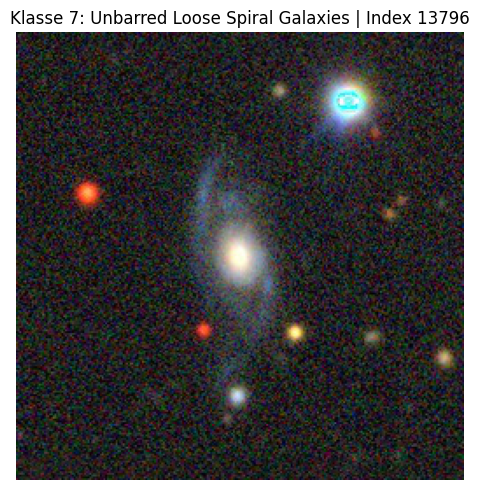

In [18]:
for class_id, sample_index, sample_image in samples:
    plt.figure(figsize=(5, 5))
    plt.imshow(sample_image)
    plt.title(f"Klasse {class_id}: {LABEL_DICT[class_id]} | Index {sample_index}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close()